# Spark Partitioning: Estimating Partition Count for File Read

## 📚 Learning Objectives

After working through this notebook, you'll understand:
- How Spark estimates the number of partitions when reading files
- The relationship between file size, default parallelism, and partition count
- Key configuration parameters that influence partitioning behavior
- Practical calculations to predict partition distribution

## 📊 Understand How Spark Estimates the Number of Partitions Required to Read a File

Spark uses an intelligent algorithm to determine optimal partition count based on:
1. **File size** - Total bytes to process
2. **Parallelism** - Available executor cores
3. **Configuration** - `spark.sql.files.maxPartitionBytes` and `spark.sql.files.openCostInBytes`

![how to decide initial no of partitions in spark.png](<attachment:how to decide initial no of partitions in spark.png>)
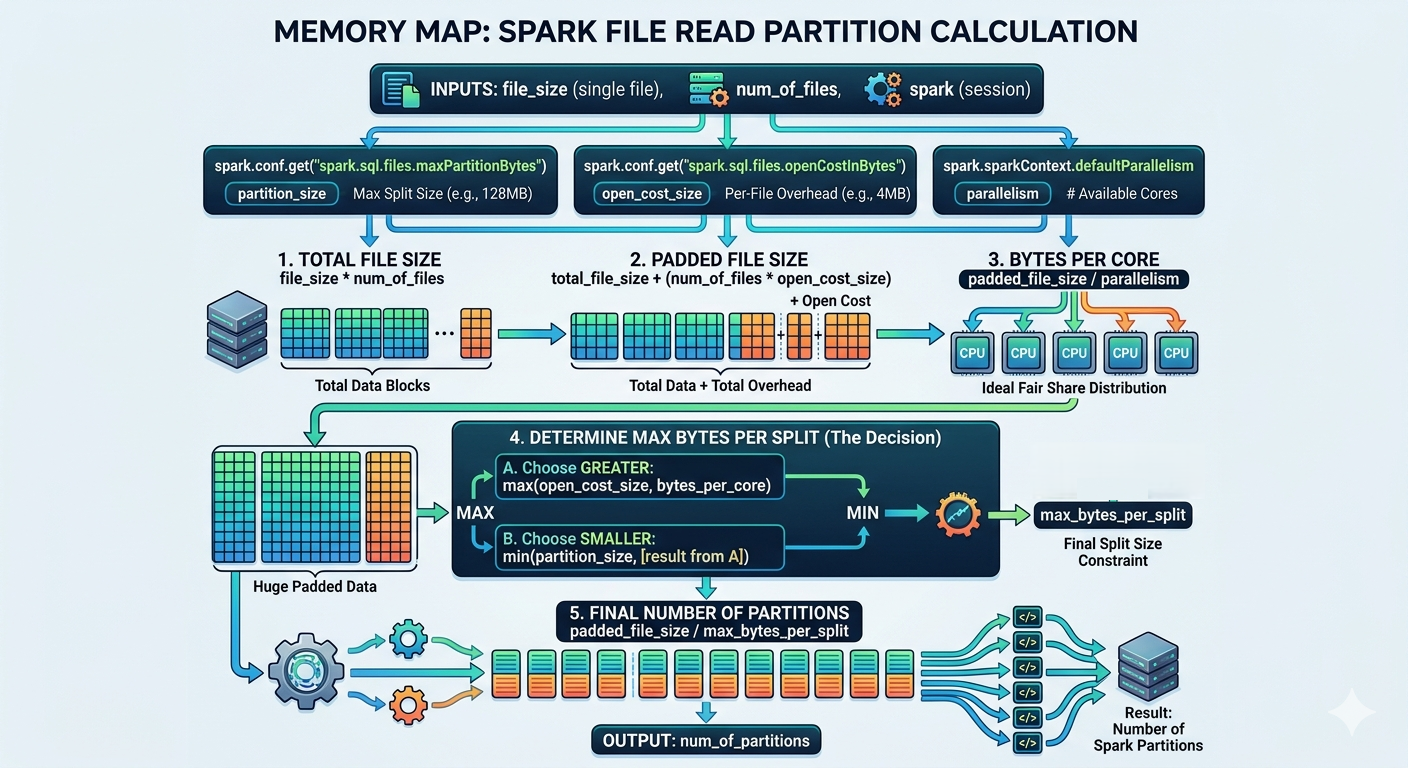

In [ ]:
import findspark
findspark.init('C:\spark-3.0.1-bin-hadoop2.7')
findspark.find()

from pyspark import SparkContext, SparkConf
from pyspark.sql import SparkSession
import pyspark.sql.functions
from pyspark.sql.types import *
import random
from datetime import datetime, timedelta

# Configure Spark with local mode using all available cores
# local[6] = 6 executor cores on local machine
conf = SparkConf().setAppName('PartitioningTutorial').setMaster('local[6]')
sc = SparkContext(conf=conf)
spark = SparkSession(sc)

# Display Spark session info
spark

## Key Concept: `spark.sparkContext.defaultParallelism`

### What it represents
- **Local Mode**: Number of logical processor cores on your machine
- **Cluster Mode**: Total number of executor cores across the cluster

### Configuration Example
```python
# Use all available cores
conf = SparkConf().setAppName('SparkApp').setMaster('local[*]')

# RDD-based operations (e.g., sc.parallelize()) respect this setting
```

### Impact
This value directly influences how Spark divides work across available computing resources. Understanding it is crucial for partition calculation.

In [ ]:
import builtins

def num_partitions(file_size, num_of_files, spark):
    """
    Calculate the number of partitions Spark will create when reading files.
    
    Algorithm:
    1. Get max partition size from Spark config (default: 128MB)
    2. Get open cost in bytes (overhead per file)
    3. Get default parallelism (executor cores)
    4. Calculate padded file size (actual size + overhead)
    5. Determine bytes per core
    6. Calculate max bytes per split (the limiting factor)
    7. Return total partition count
    
    Args:
        file_size: Size of one file in bytes
        num_of_files: Number of files to read
        spark: SparkSession object
        
    Returns:
        Number of partitions (float, rounds to int in practice)
    """
    # Check the default partition size (max bytes per partition)
    partition_size = int(spark.conf.get("spark.sql.files.maxPartitionBytes").replace("b", ""))
    
    # Check the open cost in bytes (overhead per file)
    open_cost_size = int(spark.conf.get("spark.sql.files.openCostInBytes").replace("b", ""))
    
    # Default parallelism (executor cores available)
    parallelism = int(spark.sparkContext.defaultParallelism)
    
    # Total actual file size in bytes
    total_file_size = file_size * num_of_files
    
    # Padded file size accounts for opening each file (I/O overhead)
    padded_file_size = total_file_size + (num_of_files * open_cost_size)
    
    # Calculate bytes per core for even distribution
    bytes_per_core = padded_file_size / parallelism
    
    # Max split bytes = minimum of (max partition size, max of (open cost, bytes per core))
    # This ensures partitions don't exceed max size AND utilizes all cores
    max_bytes_per_split = builtins.min(partition_size, builtins.max(open_cost_size, bytes_per_core))

    # Total number of partitions
    num_of_partitions = padded_file_size / max_bytes_per_split
    
    return num_of_partitions

Max bytes per Partition: 43275946.666666664 in bytes and 41.271158854166664 in MB


In [ ]:
# PRACTICAL EXAMPLE: Read CSV files and check partition count
df = spark.read.csv(".\\Source\\crime_data\\*.csv", header=True)

# Get number of partitions Spark created
num_parts = df.rdd.getNumPartitions()
print(f"Number of partitions: {num_parts}")
print(f"Total rows: {df.count():,}")

6

In [ ]:
import os

cpu_count = os.cpu_count()
print(f"Logical CPU cores on this machine: {cpu_count}")
print(f"Spark default parallelism: {spark.sparkContext.defaultParallelism}")
print("\nNote: In local mode, Spark uses all available cores by default (local[*])")
print("This means each core can process one partition in parallel.")

16
